In [15]:
import pydpeet as eet
import pandas as pd
from pydpeet.process.analyze.extract.half_cell_fitting import (
    get_best_half_cell_fit,
    find_best_half_cell_match,
    fit_half_cells,
    plot_half_cell_match,
)

import matplotlib.pyplot as plt

eet.set_logging_style("ERROR")

In [16]:
df_raw_1=eet.read(config="neware_8_0_0_516", input_path="/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/input_data/Input_files_checkup/20231027183923-CheckUp-1-2-AM23NMC00001.xlsx")
df_raw_1.columns

Index(['Meta_Data', 'Step_Count', 'Voltage[V]', 'Current[A]',
       'Temperature[°C]', 'Test_Time[s]', 'Date_Time', 'EIS_f[Hz]',
       'EIS_Z_Real[Ohm]', 'EIS_Z_Imag[Ohm]', 'EIS_DC[A]'],
      dtype='object')

In [17]:
df_seq_1=eet.add_primitive_segments(df_raw_1)
df_seq_1.columns


Index(['Meta_Data', 'Step_Count', 'Voltage[V]', 'Current[A]',
       'Temperature[°C]', 'Test_Time[s]', 'Date_Time', 'EIS_f[Hz]',
       'EIS_Z_Real[Ohm]', 'EIS_Z_Imag[Ohm]', 'EIS_DC[A]', 'Power[W]', 'ID',
       'Variable', 'Duration', 'Length', 'Min', 'Max', 'Avg', 'Type',
       'Direction', 'Slope'],
      dtype='object')

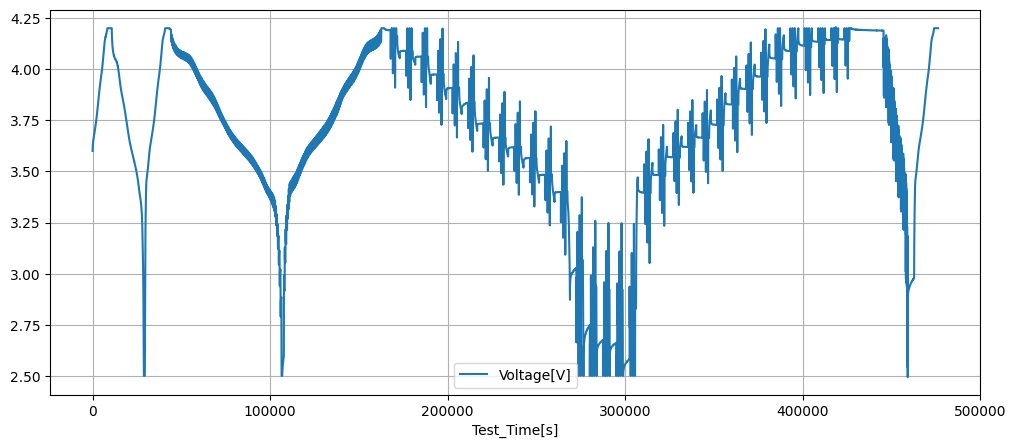

In [18]:
df_seq_1.plot(x="Test_Time[s]", y="Voltage[V]", figsize=(12, 5), grid=True)
plt.show()

In [19]:

df_soc_1=eet.add_soc(df_raw_1,df_seq_1,standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY, config=eet.lgm50lt_nmc_4800)
df_soc_1.columns

Index(['Meta_Data', 'Step_Count', 'Voltage[V]', 'Current[A]',
       'Temperature[°C]', 'Test_Time[s]', 'Date_Time', 'EIS_f[Hz]',
       'EIS_Z_Real[Ohm]', 'EIS_Z_Imag[Ohm]', 'EIS_DC[A]', 'Capacity[Ah]',
       'SOC'],
      dtype='object')

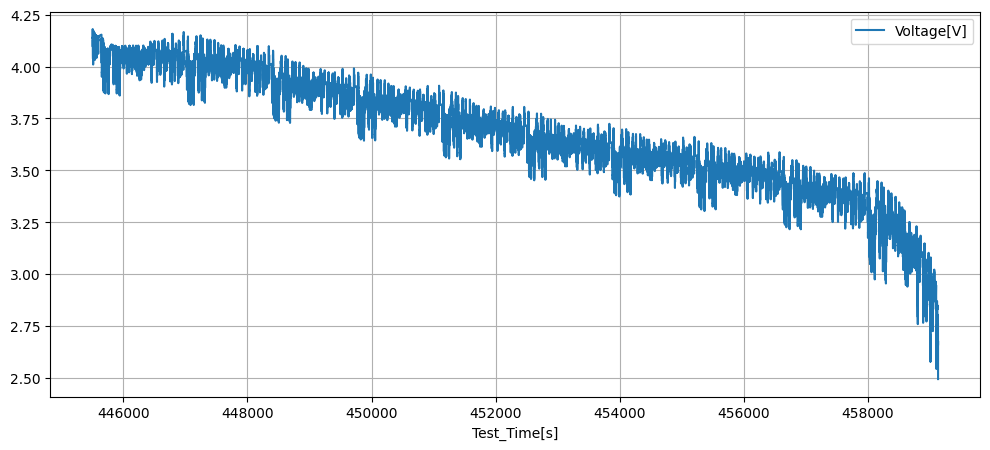

Index(['Meta_Data', 'Step_Count', 'Voltage[V]', 'Current[A]',
       'Temperature[°C]', 'Test_Time[s]', 'Date_Time', 'EIS_f[Hz]',
       'EIS_Z_Real[Ohm]', 'EIS_Z_Imag[Ohm]', 'EIS_DC[A]', 'Capacity[Ah]',
       'SOC'],
      dtype='object')

In [20]:
from pydpeet.process.analyze.extract.fuds import (
    extract_fuds
)
df_fuds_1 = extract_fuds(df_soc_1)
df_fuds_1.plot(x="Test_Time[s]", y="Voltage[V]", figsize=(12, 5), grid=True)
plt.show()
df_fuds_1.columns

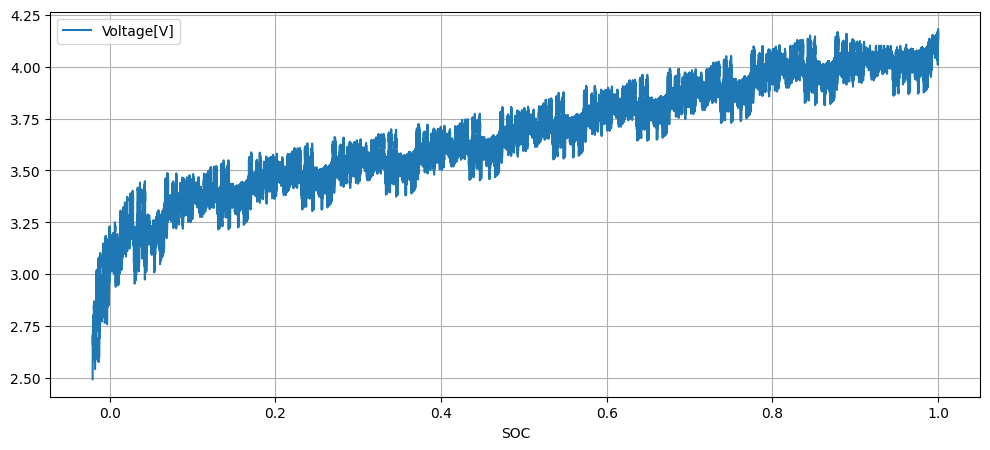

In [21]:
df_fuds_1.plot(x="SOC", y="Voltage[V]", figsize=(12, 5), grid=True)
plt.show()

In [22]:
from pydpeet.process.analyze.extract.pauses import extract_pauses

df_pause=extract_pauses(df_fuds_1,min_pause_duration_s=20)
print(len(df_pause))




60


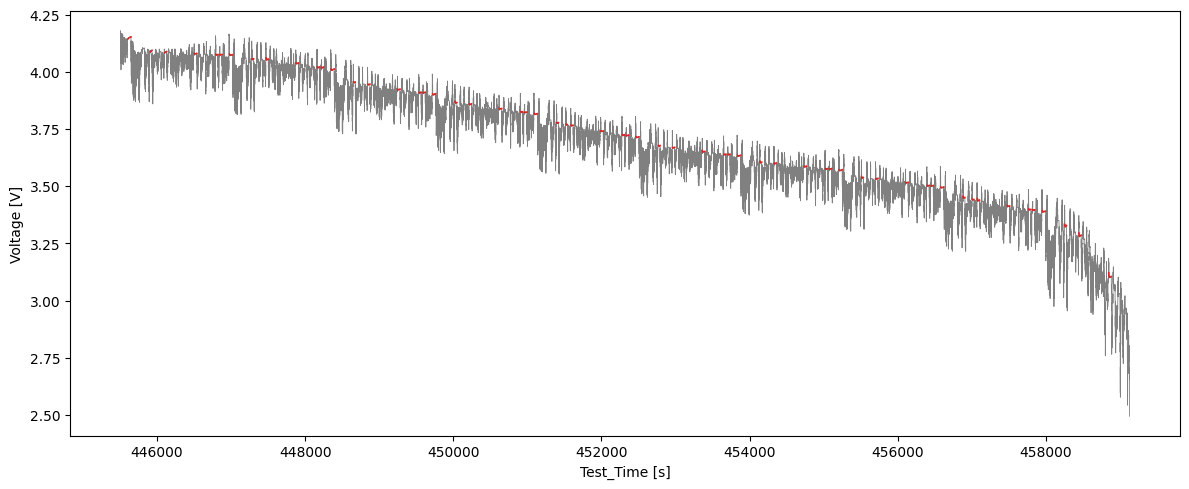

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_fuds_1["Test_Time[s]"], df_fuds_1["Voltage[V]"], color="0.5", lw=0.6)
for p in df_pause:
    ax.plot(p["Test_Time[s]"], p["Voltage[V]"], color="tab:red", lw=1.2)
ax.set_xlabel("Test_Time [s]"); ax.set_ylabel("Voltage [V]")
plt.tight_layout(); plt.show()



In [24]:
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple
anchors_simple = pauses_to_ocv_simple(df_pause)
print(f"{len(anchors_simple)} OCV-Endpunkte")
print(anchors_simple[["pause_duration_s", "SOC", "U"]].head())

60 OCV-Endpunkte
   pause_duration_s       SOC       U
0              41.9  0.993332  4.1533
1              21.9  0.950423  4.0947
2              28.9  0.934887  4.0894
3              32.9  0.905894  4.0810
4              27.9  0.890042  4.0762


In [25]:
from pydpeet.process.analyze.extract.half_cell_fitting import get_best_half_cell_fit

df_for_fit = (
    anchors_simple[["SOC", "U"]]
        .rename(columns={"U": "Voltage[V]"})
        .dropna()
        .sort_values("SOC")
        .drop_duplicates(subset="SOC")
        .reset_index(drop=True)
)

best = get_best_half_cell_fit(df_for_fit, full_cell_name="FUDS_B1")
print(best)



   RMSE[mV] FullCell                        Anode               Cathode  \
0  7.869028  FUDS_B1  Graphite, Chaouachi2021.csv  NMC811, Chen2020.csv   

   Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max  \
0       0.029365       0.714936         0.263465          0.87348   

                                      Solution_Array  
0  [0.02936547738450296, 0.7149363847825627, 0.26...  


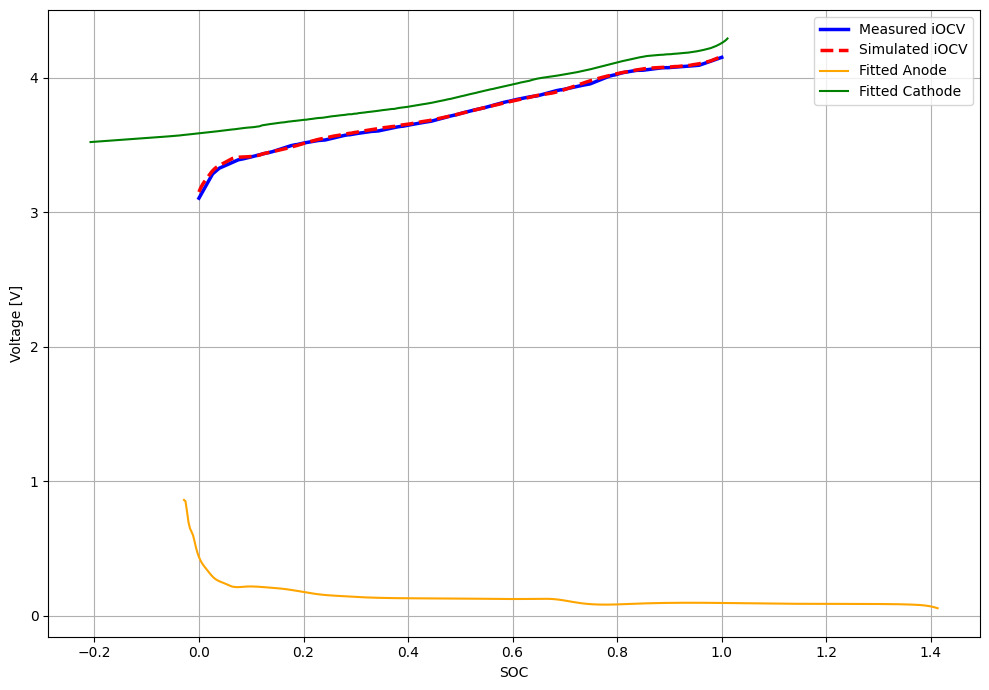

In [26]:
best_anode_file   = best["Anode"].iloc[0]
best_cathode_file = best["Cathode"].iloc[0]
solution_array    = best["Solution_Array"].iloc[0]

anode_raw   = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellAnodes/"+ best_anode_file)
cathode_raw = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellCathodes/"+best_cathode_file)

df_for_plot = df_for_fit.copy()
soc = df_for_plot["SOC"]
df_for_plot["SOC"] = (soc - soc.min()) / (soc.max() - soc.min())


plot_half_cell_match(
    full_df=df_for_plot,
    anode_df=anode_raw,
    cathode_df=cathode_raw,
    solution_array=solution_array,
    filename="BestMatch_FUDS.png",
)

In [27]:
import numpy as np
from pydpeet.process.analyze.extract.lithium_amount import extract_full_cap_mAh

# --- Methode 1: bestehende Funktion (Capacity[Ah]-Spalte oder Discharge-Integration) ---
cap_via_lib = extract_full_cap_mAh(df_fuds_1)

# --- Methode 2: SOC-basierte Schätzung (gleiche Logik wie bei den Felddaten-Chunks) ---
def estimate_capacity_via_soc_mAh(df, min_soc_distance: float = 0.5) -> float:
    d = df.dropna(subset=["SOC", "Current[A]", "Test_Time[s]"]) \
          .sort_values("Test_Time[s]") \
          .reset_index(drop=True)
    if len(d) < 2:
        return float("nan")
    soc = d["SOC"].to_numpy(dtype=float)
    t   = d["Test_Time[s]"].to_numpy(dtype=float)
    i   = d["Current[A]"].to_numpy(dtype=float)

    soc_distance = float(np.abs(np.diff(soc)).sum())
    if soc_distance < min_soc_distance:
        return float("nan")
    dt = np.diff(t)
    i_avg = (np.abs(i[1:]) + np.abs(i[:-1])) / 2.0
    ah_throughput = float((i_avg * dt).sum() / 3600.0)
    return ah_throughput / soc_distance * 1000.0

cap_via_soc = estimate_capacity_via_soc_mAh(df_fuds_1)

print(f"FUDS-Test B1")
print(f"  extract_full_cap_mAh (Lib):   {cap_via_lib:8.1f} mAh   ({cap_via_lib/1000:.3f} Ah)")
print(f"  SOC-basierte Schätzung:       {cap_via_soc:8.1f} mAh   ({cap_via_soc/1000:.3f} Ah)")
print(f"  Abweichung:                   {abs(cap_via_lib-cap_via_soc):8.1f} mAh "
      f"({100*abs(cap_via_lib-cap_via_soc)/cap_via_lib:.1f} %)")

FUDS-Test B1
  extract_full_cap_mAh (Lib):     8351.3 mAh   (8.351 Ah)
  SOC-basierte Schätzung:         4789.5 mAh   (4.789 Ah)
  Abweichung:                     3561.9 mAh (42.7 %)
